In [1]:
pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 9.9 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 10.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 10.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.1 MB 10.6 MB/s eta 0:00:01
   ---------------------- ----------------- 3.9/7.1 MB 9.5 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.1 MB 8.2 MB/s eta 0:00:01
   ---------------------------------- ----- 6.0/7.1 MB 7.5 MB/s eta 0:00:01
   ------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [34]:
df = pd.read_csv(r"C:\Users\acer\Downloads\archive (2)\medical_cost_prediction_dataset.csv")
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [12]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(5000, 20)
Index(['age', 'gender', 'bmi', 'smoker', 'diabetes', 'hypertension',
       'heart_disease', 'asthma', 'physical_activity_level', 'daily_steps',
       'sleep_hours', 'stress_level', 'doctor_visits_per_year',
       'hospital_admissions', 'medication_count', 'insurance_type',
       'insurance_coverage_pct', 'city_type', 'previous_year_cost',
       'annual_medical_cost'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64 

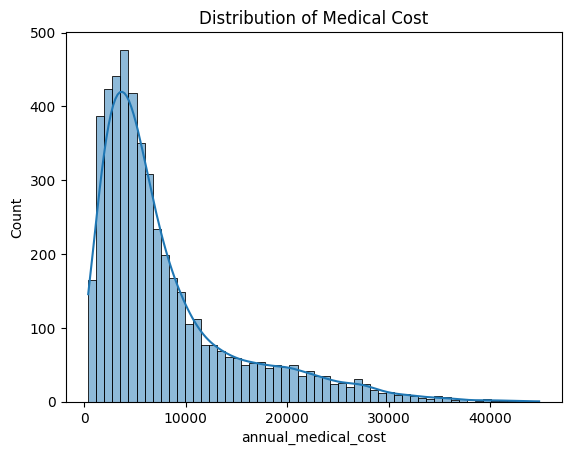

In [13]:
plt.figure()
sns.histplot(df['annual_medical_cost'], kde=True)
plt.title("Distribution of Medical Cost")
plt.show()

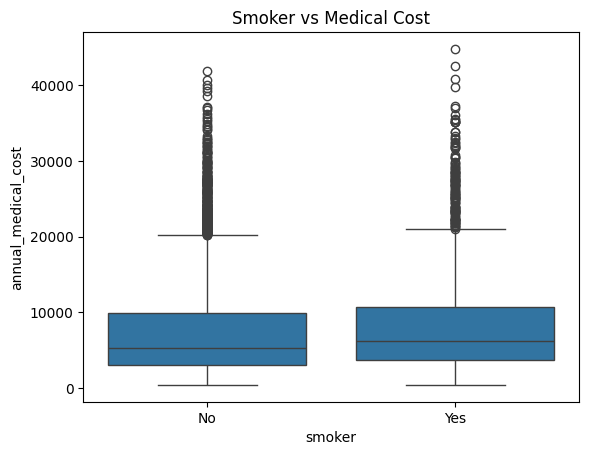

In [14]:
plt.figure()
sns.boxplot(x='smoker', y='annual_medical_cost', data=df)
plt.title("Smoker vs Medical Cost")
plt.show()

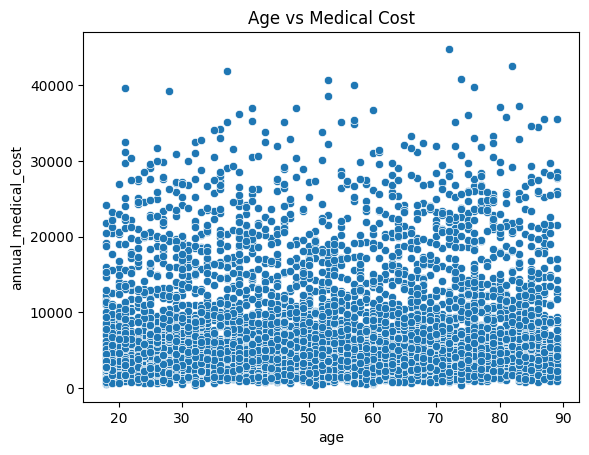

In [15]:
plt.figure()
sns.scatterplot(x='age', y='annual_medical_cost', data=df)
plt.title("Age vs Medical Cost")
plt.show()

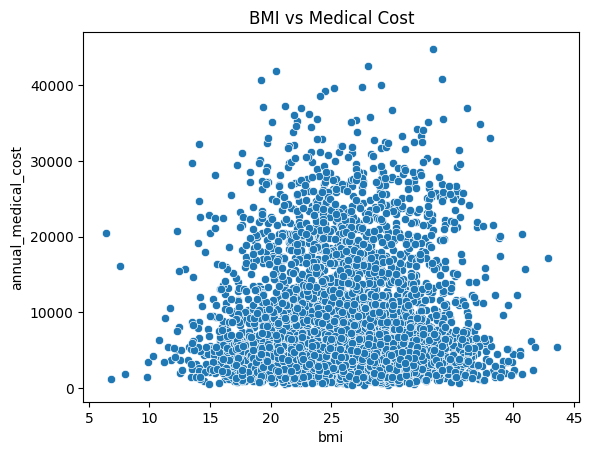

In [16]:
plt.figure()
sns.scatterplot(x='bmi', y='annual_medical_cost', data=df)
plt.title("BMI vs Medical Cost")
plt.show()

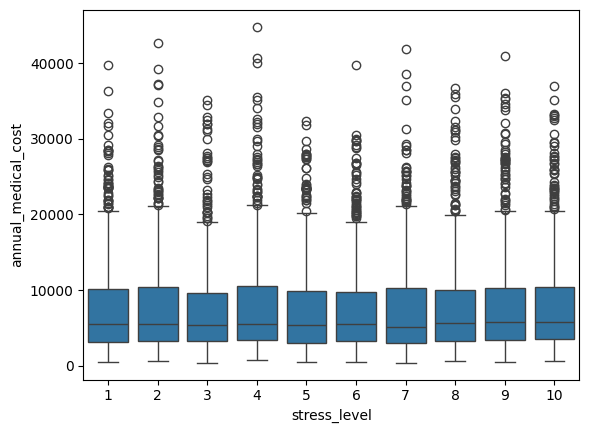

In [17]:
plt.figure()
sns.boxplot(x='stress_level', y='annual_medical_cost', data=df)
plt.show()

In [35]:
import pandas as pd

# Convert binary columns
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['smoker'] = df['smoker'].map({'No': 0, 'Yes': 1})

# Convert ALL remaining text columns automatically
df = pd.get_dummies(df, drop_first=True)

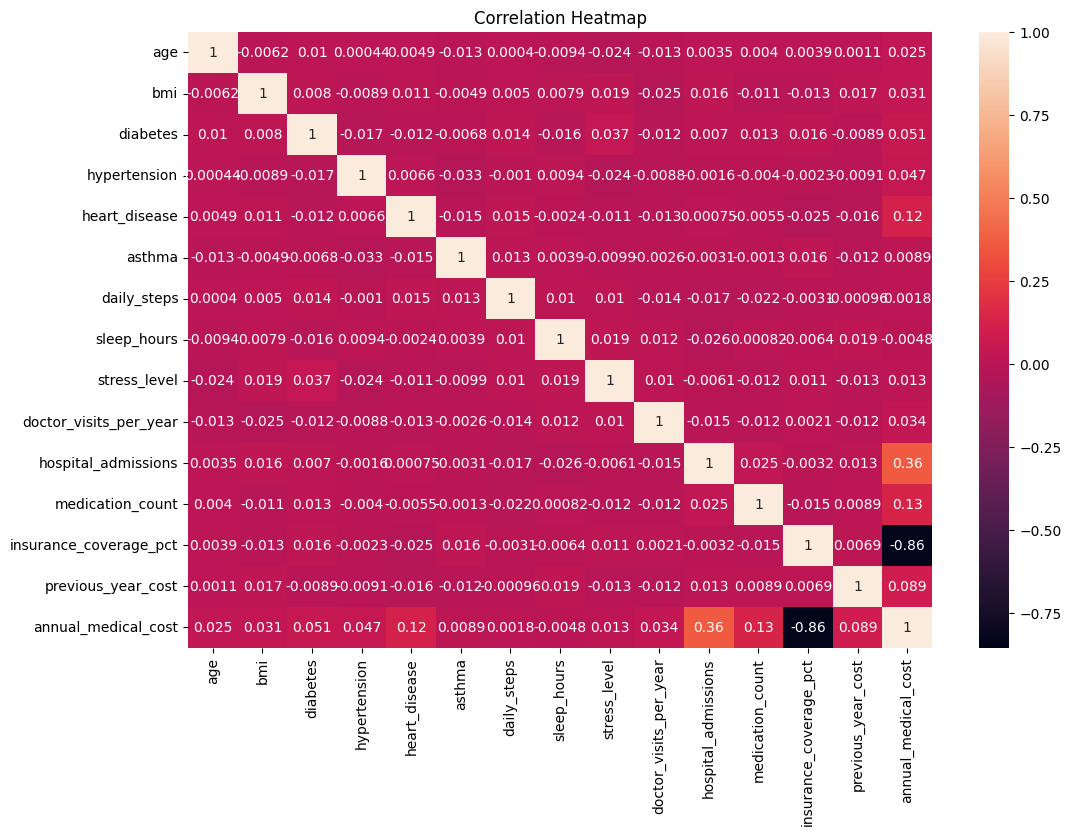

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [36]:
df.dropna(inplace=True)

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop('annual_medical_cost', axis=1)
y = df['annual_medical_cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1382.8707564856118
MSE: 4297406.062017204
R2 Score: 0.9118958807013514


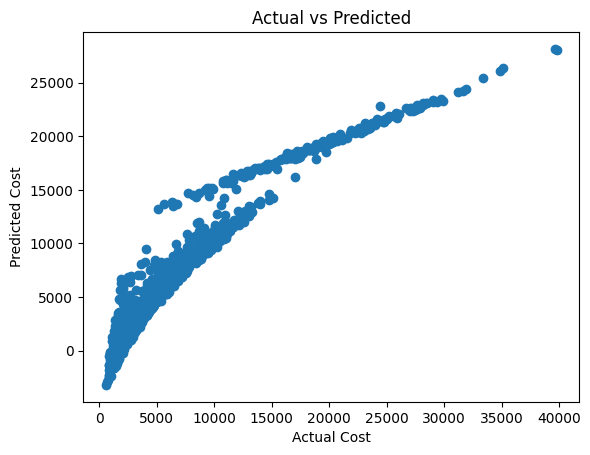

In [41]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2 Score:", r2_score(y_test, y_pred_rf))

RF R2 Score: 0.9791711891060408
